<a href="https://colab.research.google.com/github/Shizukem/B-i-12/blob/main/b%C3%A0i_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
from scipy.optimize import linprog
import pulp
import warnings
warnings.filterwarnings('ignore')

In [2]:
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size':   11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'axes.labelsize':   11,
    'figure.dpi': 130,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':   True,
    'grid.alpha':  0.35,
    'grid.linestyle': '--',
})

COLORS     = {'I': '#2980b9', 'AI': '#e74c3c', 'H': '#27ae60', 'RD': '#f39c12'}
LABELS     = {
    'I':  'Hạ tầng số (x₁)',
    'AI': 'AI & Dữ liệu (x₂)',
    'H':  'Nhân lực số (x₃)',
    'RD': 'R&D Công nghệ (x₄)',
}
keys       = ['I', 'AI', 'H', 'RD']
col_list   = [COLORS[k] for k in keys]
C_MAIN     = '#1a5276'
C_RED      = '#e74c3c'
c_coeff    = np.array([0.85, 1.20, 0.95, 1.35])

In [3]:
def solve_lp(budget=100, x3_min=20):
    c    = [-0.85, -1.20, -0.95, -1.35]
    A_ub = [
        [ 1,     1,     1,     1   ],
        [-1,     0,     0,     0   ],
        [ 0,    -1,     0,     0   ],
        [ 0,     0,    -1,     0   ],
        [ 0,     0,     0,    -1   ],
        [ 0.35, -0.65,  0.35, -0.65],
    ]
    b_ub = [budget, -25, -15, -x3_min, -10, 0]
    res  = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=[(0, None)]*4, method='highs')
    if res.status == 0:
        return {'x': res.x, 'Z': -res.fun, 'feasible': True}
    return {'feasible': False}


In [4]:
print("\n[ Câu 2.4.1 ] ─ Giải bằng scipy.optimize.linprog (HiGHS)")
print("-" * 55)
res_sc = solve_lp(100, 20)
x_opt  = res_sc['x']
Z_opt  = res_sc['Z']
print(f"  → Z* = {Z_opt:.4f} nghìn tỷ VND")
for k, xi in zip(keys, x_opt):
    print(f"     {LABELS[k]:<28}: {xi:8.2f} nghìn tỷ VND")


[ Câu 2.4.1 ] ─ Giải bằng scipy.optimize.linprog (HiGHS)
-------------------------------------------------------
  → Z* = 112.2500 nghìn tỷ VND
     Hạ tầng số (x₁)             :    25.00 nghìn tỷ VND
     AI & Dữ liệu (x₂)           :    15.00 nghìn tỷ VND
     Nhân lực số (x₃)            :    20.00 nghìn tỷ VND
     R&D Công nghệ (x₄)          :    40.00 nghìn tỷ VND


In [5]:
print("\n[ Câu 2.4.2 ] ─ PuLP + Shadow Prices")
print("-" * 55)
m  = pulp.LpProblem('VN_Budget', pulp.LpMaximize)
x1 = pulp.LpVariable('x1', lowBound=0)
x2 = pulp.LpVariable('x2', lowBound=0)
x3 = pulp.LpVariable('x3', lowBound=0)
x4 = pulp.LpVariable('x4', lowBound=0)
m += 0.85*x1 + 1.20*x2 + 0.95*x3 + 1.35*x4
m += x1 + x2 + x3 + x4 <= 100, 'budget'
m += x1 >= 25,                  'c_x1'
m += x2 >= 15,                  'c_x2'
m += x3 >= 20,                  'c_x3'
m += x4 >= 10,                  'c_x4'
m += x2 + x4 >= 0.35*(x1+x2+x3+x4), 'c_tech'
m.solve(pulp.PULP_CBC_CMD(msg=False))

Z_pulp = pulp.value(m.objective)
x_pulp = np.array([x1.value(), x2.value(), x3.value(), x4.value()])
print(f"  → Z* = {Z_pulp:.4f} (PuLP)  |  scipy = {Z_opt:.4f}  →  {'✓ khớp' if abs(Z_pulp-Z_opt)<0.01 else '✗ lệch'}")

# Shadow prices
sp_data = {
    'Ngân sách tổng (≤100)':        m.constraints['budget'].pi,
    'Sàn hạ tầng (x₁≥25)':          m.constraints['c_x1'].pi,
    'Sàn AI (x₂≥15)':               m.constraints['c_x2'].pi,
    'Sàn nhân lực (x₃≥20)':         m.constraints['c_x3'].pi,
    'Sàn R&D (x₄≥10)':              m.constraints['c_x4'].pi,
    'CN chiến lược (x₂+x₄≥35%)':    m.constraints['c_tech'].pi,
}
sl_data = {
    'Ngân sách tổng (≤100)':        m.constraints['budget'].slack,
    'Sàn hạ tầng (x₁≥25)':          m.constraints['c_x1'].slack,
    'Sàn AI (x₂≥15)':               m.constraints['c_x2'].slack,
    'Sàn nhân lực (x₃≥20)':         m.constraints['c_x3'].slack,
    'Sàn R&D (x₄≥10)':              m.constraints['c_x4'].slack,
    'CN chiến lược (x₂+x₄≥35%)':    m.constraints['c_tech'].slack,
}
print(f"\n  {'Ràng buộc':<32} {'Shadow':>8} {'Slack':>8}  Trạng thái")
print("  " + "-"*68)
for name in sp_data:
    sp = sp_data[name]
    sl = sl_data[name]
    st = 'Binding (chặt)' if abs(sl) < 1e-3 else 'Còn dư'
    print(f"  {name:<32} {sp:>8.4f} {sl:>8.3f}  {st}")

sp_budget = sp_data['Ngân sách tổng (≤100)']
print(f"\n  → Shadow price ngân sách = {sp_budget:.4f}")
print(f"     Mỗi 1 nghìn tỷ tăng thêm → Z* tăng {sp_budget:.4f} nghìn tỷ VND GDP")


[ Câu 2.4.2 ] ─ PuLP + Shadow Prices
-------------------------------------------------------
  → Z* = 112.2500 (PuLP)  |  scipy = 112.2500  →  ✓ khớp

  Ràng buộc                          Shadow    Slack  Trạng thái
  --------------------------------------------------------------------
  Ngân sách tổng (≤100)              1.3500   -0.000  Binding (chặt)
  Sàn hạ tầng (x₁≥25)               -0.5000   -0.000  Binding (chặt)
  Sàn AI (x₂≥15)                    -0.1500   -0.000  Binding (chặt)
  Sàn nhân lực (x₃≥20)              -0.4000   -0.000  Binding (chặt)
  Sàn R&D (x₄≥10)                   -0.0000  -30.000  Còn dư
  CN chiến lược (x₂+x₄≥35%)         -0.0000  -20.000  Còn dư

  → Shadow price ngân sách = 1.3500
     Mỗi 1 nghìn tỷ tăng thêm → Z* tăng 1.3500 nghìn tỷ VND GDP


In [6]:
print("\n[ Câu 2.4.3 ] ─ Phân tích độ nhạy ngân sách 70 → 200")
print("-" * 55)
budgets_range = np.arange(70, 201, 5)
Z_curve = []
alloc_matrix = {k: [] for k in keys}

for B in budgets_range:
    r = solve_lp(B, 20)
    if r['feasible']:
        Z_curve.append(r['Z'])
        for i, k in enumerate(keys):
            alloc_matrix[k].append(r['x'][i])
    else:
        Z_curve.append(np.nan)
        for k in keys:
            alloc_matrix[k].append(np.nan)

Z_curve = np.array(Z_curve)

print(f"  {'B':>8}  {'Z*':>10}   x₁(I)   x₂(AI)   x₃(H)  x₄(R&D)")
print("  " + "-"*60)
for B_s in [100, 120, 140, 160, 180, 200]:
    r = solve_lp(B_s, 20)
    if r['feasible']:
        x = r['x']
        print(f"  {B_s:>8,}  {r['Z']:>10.2f}  {x[0]:>7.1f}  {x[1]:>7.1f}  {x[2]:>7.1f}  {x[3]:>7.1f}")


[ Câu 2.4.3 ] ─ Phân tích độ nhạy ngân sách 70 → 200
-------------------------------------------------------
         B          Z*   x₁(I)   x₂(AI)   x₃(H)  x₄(R&D)
  ------------------------------------------------------------
       100      112.25     25.0     15.0     20.0     40.0
       120      139.25     25.0     15.0     20.0     60.0
       140      166.25     25.0     15.0     20.0     80.0
       160      193.25     25.0     15.0     20.0    100.0
       180      220.25     25.0     15.0     20.0    120.0
       200      247.25     25.0     15.0     20.0    140.0


In [7]:
print("\n[ Câu 2.4.4 ] ─ Kịch bản x₃ ≥ 30 (ưu tiên nhân lực)")
print("-" * 55)
res_30 = solve_lp(100, 30)
if res_30['feasible']:
    dZ = res_30['Z'] - Z_opt
    print(f"  → KHẢ THI  |  Z* = {res_30['Z']:.4f}  (ΔZ = {dZ:.4f}, tức {dZ/Z_opt*100:.2f}%)")
    for k, xi in zip(keys, res_30['x']):
        print(f"     {LABELS[k]:<28}: {xi:8.2f}")
else:
    print("  → KHÔNG khả thi")


[ Câu 2.4.4 ] ─ Kịch bản x₃ ≥ 30 (ưu tiên nhân lực)
-------------------------------------------------------
  → KHẢ THI  |  Z* = 108.2500  (ΔZ = -4.0000, tức -3.56%)
     Hạ tầng số (x₁)             :    25.00
     AI & Dữ liệu (x₂)           :    15.00
     Nhân lực số (x₃)            :    30.00
     R&D Công nghệ (x₄)          :    30.00


In [8]:
print("\n  Đang vẽ biểu đồ chính...")

fig = plt.figure(figsize=(18, 22))
fig.patch.set_facecolor('white')
gs = GridSpec(3, 2, figure=fig, hspace=0.48, wspace=0.33)


  Đang vẽ biểu đồ chính...


In [9]:
ax1 = fig.add_subplot(gs[0, 0])
wedges, texts, autotexts = ax1.pie(
    x_opt,
    labels=[f"{LABELS[k]}\n{v:.0f} ng.tỷ" for k, v in zip(keys, x_opt)],
    autopct='%1.1f%%',
    colors=col_list,
    startangle=90,
    pctdistance=0.70,
    wedgeprops=dict(edgecolor='white', linewidth=2.5),
)
for at in autotexts:
    at.set_fontsize(10.5)
    at.set_fontweight('bold')
ax1.set_title(f'Câu 2.4.1-2 — Phân bổ ngân sách tối ưu\n'
              f'B = 100 nghìn tỷ  |  Z* = {Z_opt:.2f} nghìn tỷ VND', pad=14)

Text(0.5, 1.0, 'Câu 2.4.1-2 — Phân bổ ngân sách tối ưu\nB = 100 nghìn tỷ  |  Z* = 112.25 nghìn tỷ VND')

In [10]:
ax2 = fig.add_subplot(gs[0, 1])
sp_names = list(sp_data.keys())
sp_vals  = list(sp_data.values())
bar_c2   = [C_MAIN if v > 0 else C_RED for v in sp_vals]
bars2    = ax2.barh(sp_names, sp_vals, color=bar_c2, alpha=0.85, height=0.55)
ax2.axvline(0, color='black', lw=1)
for bar, v in zip(bars2, sp_vals):
    off = 0.012 if v >= 0 else -0.012
    ha  = 'left' if v >= 0 else 'right'
    ax2.text(v + off, bar.get_y() + bar.get_height()/2,
             f'{v:.4f}', va='center', ha=ha, fontsize=9.5, fontweight='bold')
ax2.set_title('Câu 2.4.2 — Shadow Prices\n(Giá đối ngẫu từng ràng buộc)', pad=14)
ax2.set_xlabel('Nghìn tỷ VND GDP / nghìn tỷ VND nới ràng buộc')
ax2.tick_params(axis='y', labelsize=9)
patch_pos = mpatches.Patch(color=C_MAIN, label='Binding – nới lỏng → Z* tăng')
patch_neg = mpatches.Patch(color=C_RED,  label='Binding âm / Còn dư')
ax2.legend(handles=[patch_pos, patch_neg], fontsize=8.5, loc='lower right')

In [11]:
ax3 = fig.add_subplot(gs[1, :])
mask   = ~np.isnan(Z_curve)
slope  = np.polyfit(budgets_range[mask], Z_curve[mask], 1)[0]
ax3.plot(budgets_range[mask], Z_curve[mask], 'o-',
         color=C_MAIN, lw=2.5, ms=5, label='Z*(B)')
ax3.fill_between(budgets_range[mask], Z_curve[mask], alpha=0.10, color=C_MAIN)

marker_cfg = [
    (100, '#e74c3c'), (120, '#27ae60'), (140, '#f39c12'),
    (160, '#8e44ad'), (180, '#16a085'),
]
for B_m, c_m in marker_cfg:
    idx = np.where(budgets_range == B_m)[0]
    if len(idx):
        z_m = Z_curve[idx[0]]
        ax3.axvline(B_m, color=c_m, ls='--', lw=1.4, alpha=0.7)
        ax3.scatter([B_m], [z_m], color=c_m, s=90, zorder=6)
        ax3.annotate(f"B={B_m}\nZ*={z_m:.1f}",
                     (B_m, z_m), textcoords='offset points',
                     xytext=(7, -22), fontsize=8.8, color=c_m, fontweight='bold')

ax3.set_title(f'Câu 2.4.3 — Đường cong Z*(B): Giá trị tối ưu theo ngân sách\n'
              f'Độ dốc ≈ {slope:.4f} → shadow price ngân sách (xác nhận = {sp_budget:.4f})')
ax3.set_xlabel('Ngân sách tổng B (nghìn tỷ VND)')
ax3.set_ylabel('Z* — GDP tăng thêm kỳ vọng (nghìn tỷ VND)')
ax3.legend(fontsize=10)
ax3.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.1f}'))

In [12]:
ax4 = fig.add_subplot(gs[2, 0])
B_list   = [80, 100, 120, 140, 160, 180, 200]
alloc_at = {}
for B_s in B_list:
    r = solve_lp(B_s, 20)
    if r['feasible']:
        alloc_at[B_s] = r['x']

xpos4   = np.arange(len(B_list))
bot4    = np.zeros(len(B_list))
for i, k in enumerate(keys):
    vals4 = np.array([alloc_at[B][i] if B in alloc_at else 0 for B in B_list])
    ax4.bar(xpos4, vals4, bottom=bot4, label=LABELS[k],
            color=col_list[i], alpha=0.85, width=0.62)
    bot4 += vals4

ax4.set_xticks(xpos4)
ax4.set_xticklabels([f'{B:,}' for B in B_list], fontsize=9.5)
ax4.set_title('Câu 2.4.3 — Cơ cấu phân bổ tối ưu\ntheo từng mức ngân sách')
ax4.set_xlabel('Ngân sách (nghìn tỷ VND)')
ax4.set_ylabel('Phân bổ (nghìn tỷ VND)')
ax4.legend(fontsize=8.5, loc='upper left')

In [13]:
import os
ax5 = fig.add_subplot(gs[2, 1])
sc_labels = ['Gốc (x₃≥20)', 'Ưu tiên NL (x₃≥30)']
sc_vals   = [x_opt, res_30['x'] if res_30['feasible'] else np.zeros(4)]
sc_Z      = [Z_opt, res_30['Z'] if res_30['feasible'] else 0]
n_sc      = len(sc_labels)
n_k       = len(keys)
width5    = 0.18
xpos5     = np.arange(n_sc)

for i, k in enumerate(keys):
    offsets5 = xpos5 + (i - (n_k-1)/2) * width5
    heights5 = [sc_vals[s][i] for s in range(n_sc)]
    ax5.bar(offsets5, heights5, width=width5, color=col_list[i],
            alpha=0.85, label=LABELS[k])

ax5.set_xticks(xpos5)
ax5.set_xticklabels(sc_labels, fontsize=10.5)
ax5.set_ylabel('Phân bổ (nghìn tỷ VND)')
dZ_label = (res_30['Z'] - Z_opt) if res_30['feasible'] else 0
ax5.set_title(f'Câu 2.4.4 — Gốc vs. Ưu tiên Nhân lực số\n'
              f'ΔZ* = {dZ_label:.3f} nghìn tỷ ({dZ_label/Z_opt*100:.2f}%)')
ax5.legend(fontsize=8.5, loc='upper right')
# Z* annotation
for s in range(n_sc):
    ax5.text(xpos5[s], max(sc_vals[s]) + 1.5,
             f'Z*={sc_Z[s]:.2f}', ha='center',
             fontsize=10, fontweight='bold', color=C_MAIN)

fig.suptitle(
    'BÀI 2 — QUY HOẠCH TUYẾN TÍNH PHÂN BỔ NGÂN SÁCH SỐ\n'
    'max Z = 0.85x₁ + 1.20x₂ + 0.95x₃ + 1.35x₄   |   Ngân sách 100 nghìn tỷ VND',
    fontsize=15, fontweight='bold', y=0.997,
)

output_dir = '/mnt/user-data/outputs/'
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, 'bai2_lp_ngan_sach.png'),
            bbox_inches='tight', dpi=150, facecolor='white')
plt.close(fig)
print("  [✓] bai2_lp_ngan_sach.png — đã lưu")

  [✓] bai2_lp_ngan_sach.png — đã lưu


Main plot (6 panels):


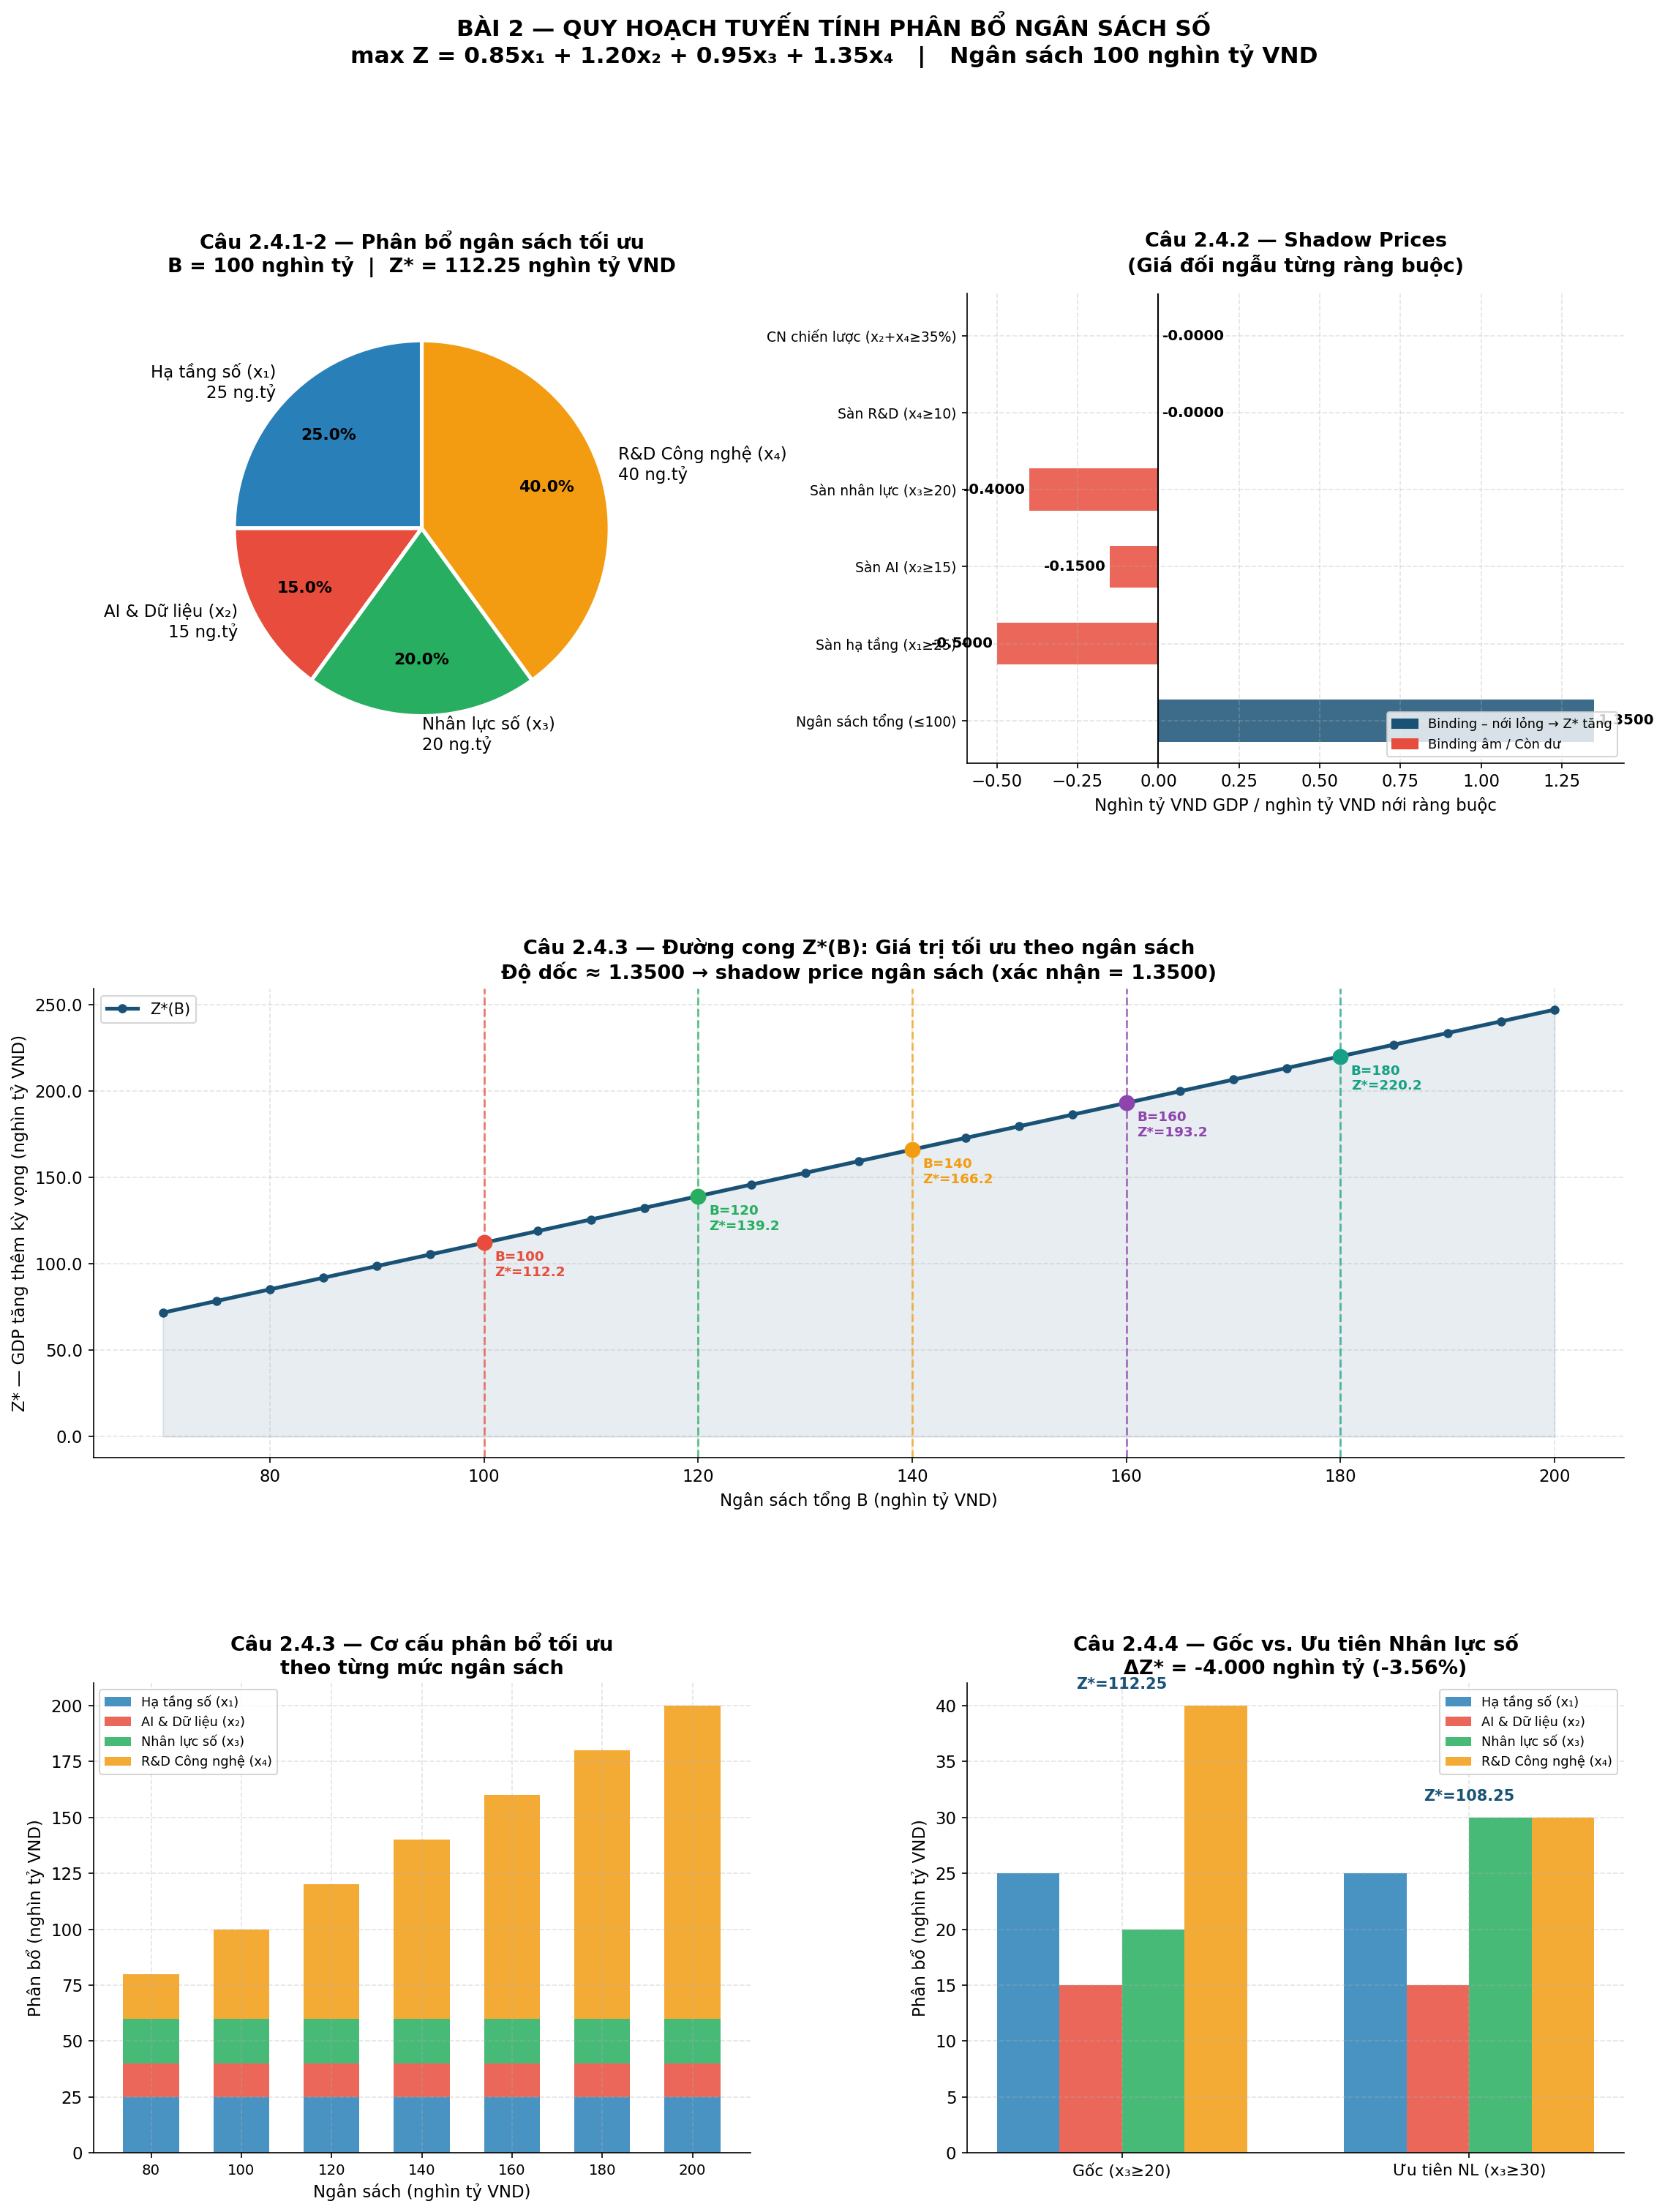

In [15]:
from IPython.display import Image, display

print('Main plot (6 panels):')
display(Image('/mnt/user-data/outputs/bai2_lp_ngan_sach.png'))